In [32]:
import pandas as pd

coadd = True

# Load the data
if coadd: 
    data = pd.read_csv('coadd_ensemble_simplified.csv')
else:
    data = pd.read_csv('ensemble_simplified.csv')
data

,SMILES,Hit,true_label,mean_5_0,std_dev_5_0,mean_5_1,std_dev_5_1,mean_5_2,std_dev_5_2,mean_5_3,...,mean_15_1,std_dev_15_1,mean_15_2,std_dev_15_2,mean_15_3,std_dev_15_3,mean_15_4,std_dev_15_4,mean_20_0,std_dev_20_0
0,C1B2CC3CC1CC(C2)C3,0.0,0.0,0.001930,0.000681,0.001971,0.000412,0.001580,0.000168,0.001913,...,0.001881,0.000609,0.001804,0.000580,0.002047,0.000654,0.001991,0.000676,0.001958,0.000632
1,CC1CC(P(=O)(c2ccccc2)c2ccccc2)OB(c2ccccc2)O1,0.0,0.0,0.001639,0.000323,0.001610,0.000661,0.001951,0.000518,0.001837,...,0.001683,0.000479,0.001840,0.000403,0.001820,0.000446,0.001772,0.000473,0.001747,0.000450
2,OB1OCc2ccccc21,1.0,1.0,0.002227,0.000545,0.002658,0.000505,0.002777,0.000646,0.002525,...,0.002439,0.000536,0.002585,0.000554,0.002622,0.000462,0.002652,0.000500,0.002555,0.000509
3,Cc1ccc(B2Nc3ccccc3N2)cc1,0.0,0.0,0.001477,0.000465,0.001523,0.000365,0.001545,0.000436,0.001698,...,0.001398,0.000334,0.001486,0.000380,0.001525,0.000391,0.001541,0.000422,0.001508,0.000407
4,CC1CC(P(c2ccccc2)c2ccccc2)OB(c2ccccc2)O1,0.0,0.0,0.001276,0.000163,0.001516,0.000819,0.001713,0.000752,0.001452,...,0.001345,0.000575,0.001433,0.000562,0.001421,0.000548,0.001417,0.000552,0.001376,0.000514
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81685,c1csc(CNCc2cccs2)c1,0.0,0.0,0.001770,0.000191,0.001679,0.000351,0.001513,0.000198,0.001671,...,0.001587,0.000352,0.001532,0.000280,0.001645,0.000316,0.001597,0.000289,0.001600,0.000335
81686,Clc1ccc(NCc2cccs2)cc1,0.0,0.0,0.005575,0.000793,0.005354,0.000904,0.005670,0.000768,0.005926,...,0.005187,0.000907,0.005473,0.001061,0.005499,0.001058,0.005371,0.000956,0.005363,0.001016
81687,O=[As](O)(c1cccs1)c1cccs1,0.0,0.0,0.001690,0.000551,0.001606,0.000208,0.001729,0.000292,0.001543,...,0.001655,0.000310,0.001806,0.000501,0.001892,0.000457,0.001793,0.000401,0.001779,0.000460
81688,COc1cc([C@@H]2c3cc4c(cc3[C@@H](OC3OC5CO[C@@H](...,0.0,0.0,0.000959,0.000246,0.000795,0.000180,0.000980,0.000150,0.000846,...,0.000875,0.000284,0.000900,0.000277,0.000872,0.000271,0.000844,0.000219,0.000872,0.000256


In [24]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    accuracy_score, precision_score, recall_score, confusion_matrix
)

def compute_classification_metrics(probs, labels, threshold=0.5):
    """
    Compute classification metrics given predicted probabilities and true labels.

    Parameters:
        probs (array-like): predicted probabilities
        labels (array-like): true binary labels (0 or 1)
        threshold (float): threshold to convert probs to binary predictions

    Returns:
        dict: containing AUROC, AUPRC, accuracy, precision, recall, TP, FP, TN, FN
    """
    # Binary predictions
    preds = (probs >= threshold).astype(int)

    # Basic metrics
    auroc = roc_auc_score(labels, probs)
    auprc = average_precision_score(labels, probs)
    acc = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, zero_division=0)
    rec = recall_score(labels, preds, zero_division=0)

    # Confusion matrix: tn, fp, fn, tp
    tn, fp, fn, tp = confusion_matrix(labels, preds).ravel()

    return {
        'AUROC': auroc,
        'AUPRC': auprc,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'TP': tp,
        'FP': fp,
        'TN': tn,
        'FN': fn
    }

compute_classification_metrics(data["mean_5_0"], data["true_label"])

{'AUROC': np.float64(0.9825447667722667),
 'AUPRC': np.float64(0.6591488417708111),
 'Accuracy': 0.9969049829774064,
 'Precision': 0.8444444444444444,
 'Recall': 0.5352112676056338,
 'TP': np.int64(38),
 'FP': np.int64(7),
 'TN': np.int64(12846),
 'FN': np.int64(33)}

Ensemble size 5: Correlation between std_dev and absolute error = 0.5926
Ensemble size 10: Correlation between std_dev and absolute error = 0.5964
Ensemble size 15: Correlation between std_dev and absolute error = 0.6101
Ensemble size 20: Correlation between std_dev and absolute error = 0.6072


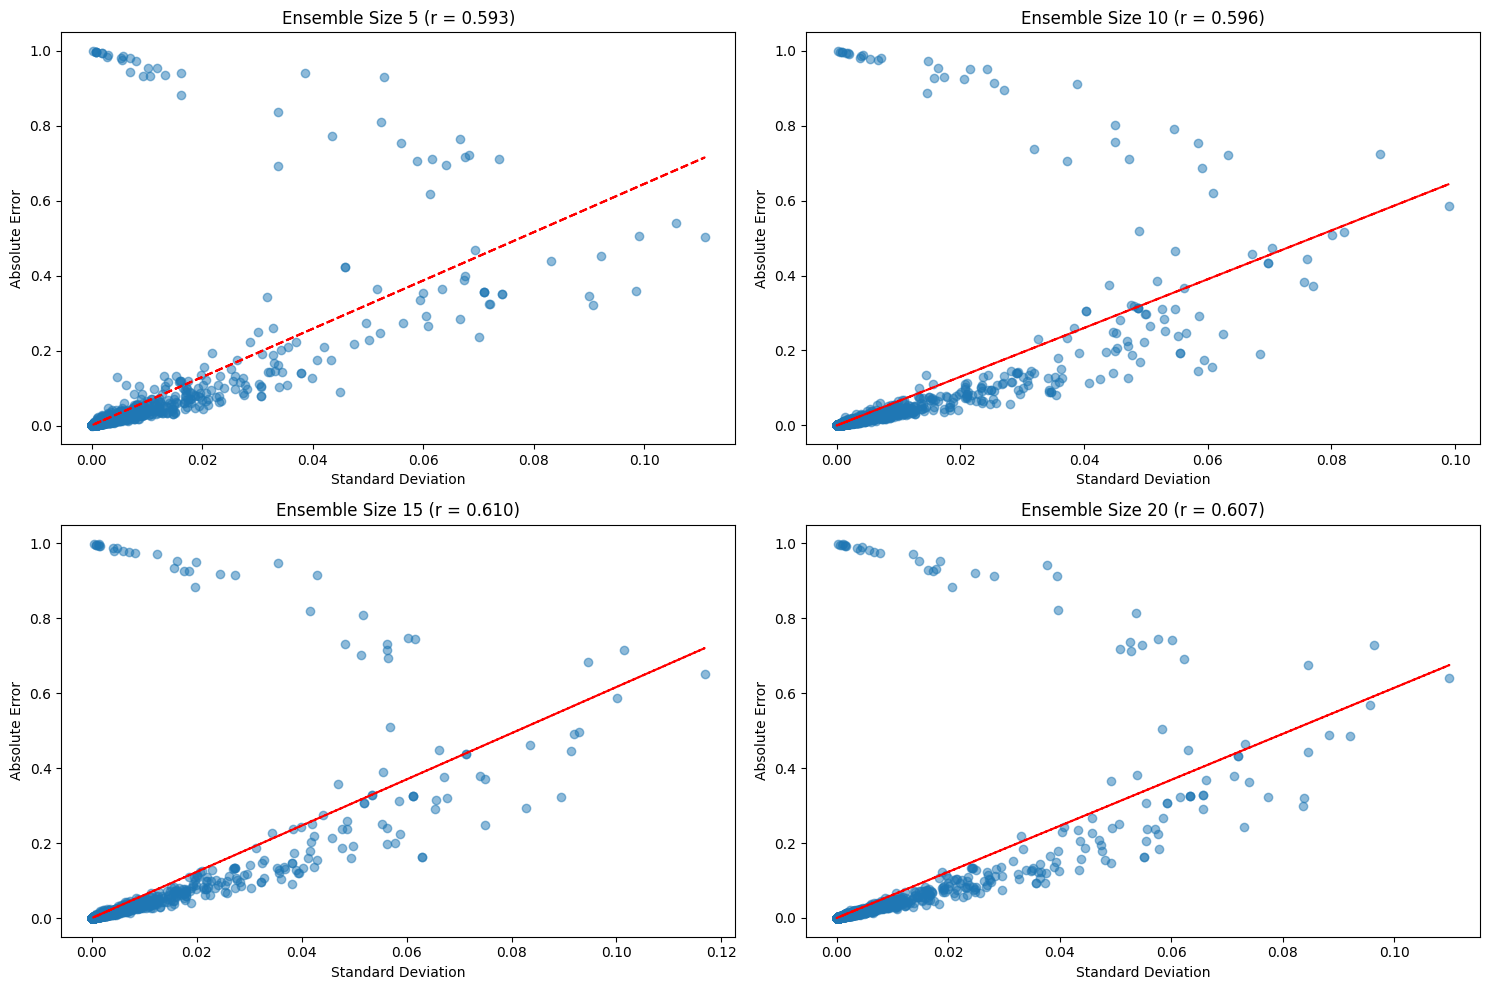

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Calculate correlations for each ensemble size, focusing on subensemble 0
ensemble_sizes = [5, 10, 15, 20]
correlations = {}
plt.figure(figsize=(15, 10))

for i, size in enumerate(ensemble_sizes):
    # For each ensemble size, get the mean and std_dev columns for subensemble 0
    mean_col = f'mean_{size}_0'
    std_dev_col = f'std_dev_{size}_0'
    
    # Calculate absolute error compared to ground truth
    absolute_errors = np.abs(data[mean_col] - data['true_label'])
    
    # Calculate Pearson correlation between std_dev and absolute error
    correlation, p_value = pearsonr(data[std_dev_col], absolute_errors)
    correlations[size] = correlation
    
    # Create subplot for this ensemble size
    plt.subplot(2, 2, i+1)
    plt.scatter(data[std_dev_col], absolute_errors, alpha=0.5)
    plt.title(f'Ensemble Size {size} (r = {correlation:.3f})')
    plt.xlabel('Standard Deviation')
    plt.ylabel('Absolute Error')
    
    # Add a trend line
    z = np.polyfit(data[std_dev_col], absolute_errors, 1)
    plt.plot(data[std_dev_col], np.polyval(z, data[std_dev_col]), 'r--')

plt.tight_layout()
if coadd: plt.savefig('coadd_test_set_correlation_plots.png') 
else: plt.savefig('collins_test_set_correlation_plots.png')

# Print correlation results
for size, corr in correlations.items():
    print(f"Ensemble size {size}: Correlation between std_dev and absolute error = {corr:.4f}")

In [33]:
from sklearn.metrics import roc_auc_score, average_precision_score

# y_true: 1-D array-like of ground-truth labels (0 = inactive, 1 = active)
# y_score: 1-D array-like of predicted probabilities or confidence scores for the positive class

y_true = data["true_label"]
y_score = data["mean_5_0"]

auroc  = roc_auc_score(y_true, y_score)          # Area Under ROC
auprc  = average_precision_score(y_true, y_score)  # Area Under Precision-Recall Curve (AUPRC)

print(f"AUROC : {auroc:.4f}")
print(f"AUPRC : {auprc:.4f}")


AUROC : 0.8475
AUPRC : 0.1700


Ensemble size 5: Correlation between std_dev and absolute error = -0.6294
Ensemble size 10: Correlation between std_dev and absolute error = -0.6600
Ensemble size 15: Correlation between std_dev and absolute error = -0.6170
Ensemble size 20: Correlation between std_dev and absolute error = -0.6651


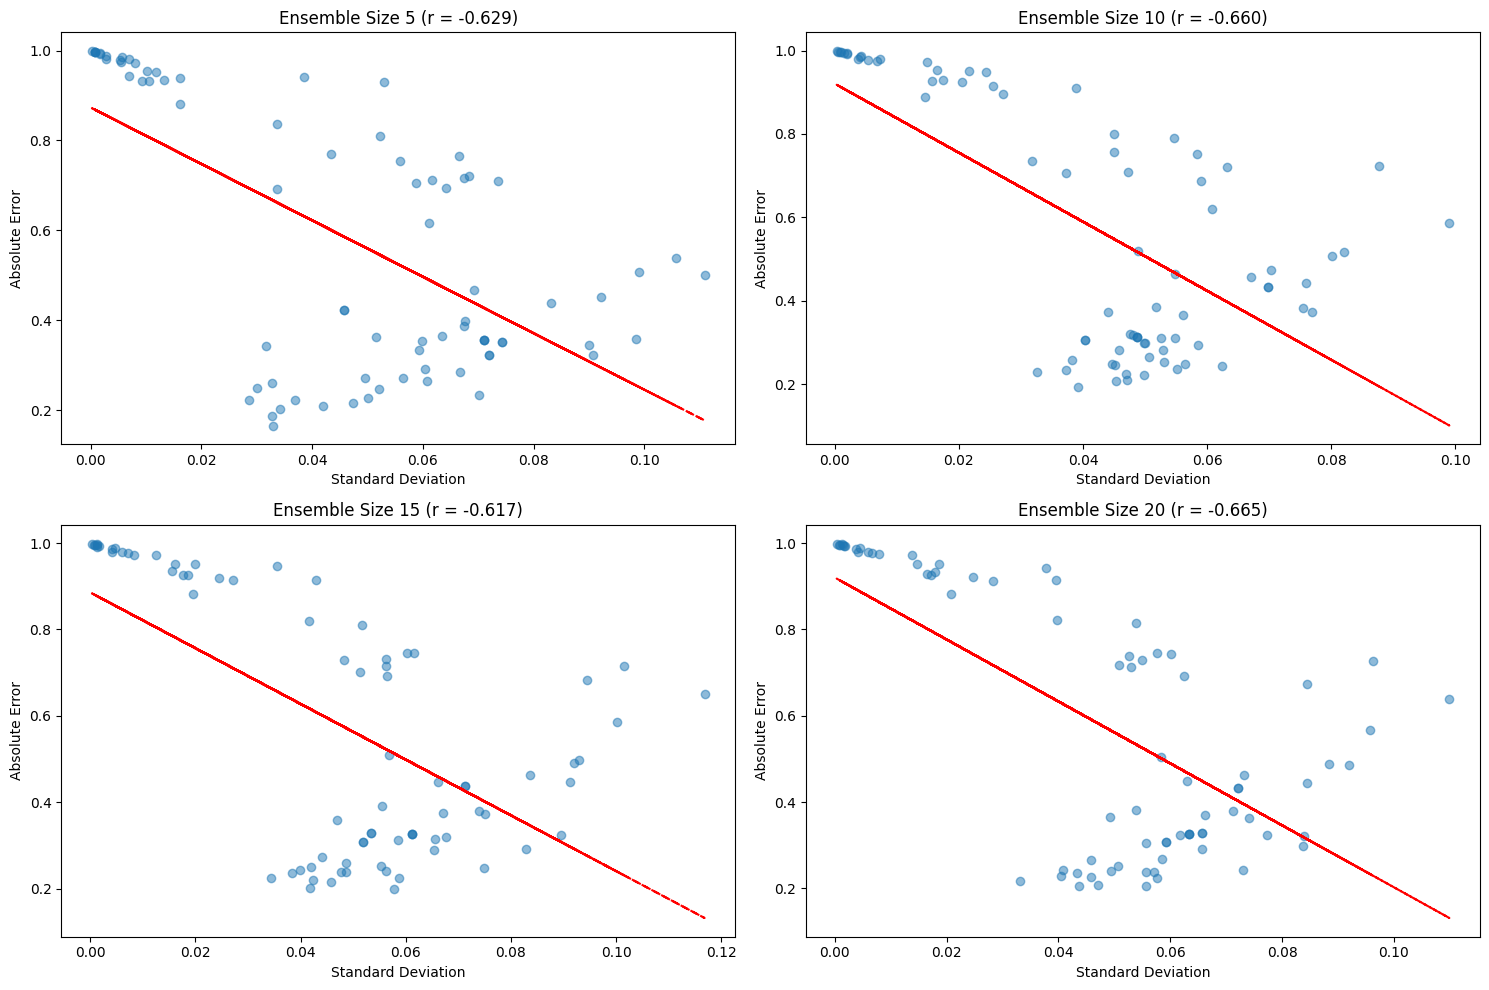

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

data_filtered = data.copy()
data_filtered["error"] = absolute_errors = np.abs(data_filtered[mean_col] - data_filtered['true_label'])
data_filtered = data_filtered[data_filtered["error"] > 0.2]

# Calculate correlations for each ensemble size, focusing on subensemble 0
ensemble_sizes = [5, 10, 15, 20]
correlations = {}
plt.figure(figsize=(15, 10))

for i, size in enumerate(ensemble_sizes):
    # For each ensemble size, get the mean and std_dev columns for subensemble 0
    mean_col = f'mean_{size}_0'
    std_dev_col = f'std_dev_{size}_0'
    
    # Calculate absolute error compared to ground truth
    absolute_errors = np.abs(data_filtered[mean_col] - data_filtered['true_label'])
    
    # Calculate Pearson correlation between std_dev and absolute error
    correlation, p_value = pearsonr(data_filtered[std_dev_col], absolute_errors)
    correlations[size] = correlation
    
    # Create subplot for this ensemble size
    plt.subplot(2, 2, i+1)
    plt.scatter(data_filtered[std_dev_col], absolute_errors, alpha=0.5)
    plt.title(f'Ensemble Size {size} (r = {correlation:.3f})')
    plt.xlabel('Standard Deviation')
    plt.ylabel('Absolute Error')
    
    # Add a trend line
    z = np.polyfit(data_filtered[std_dev_col], absolute_errors, 1)
    plt.plot(data_filtered[std_dev_col], np.polyval(z, data_filtered[std_dev_col]), 'r--')

plt.tight_layout()
if coadd: plt.savefig('coadd_test_set_correlation_plots.png') 
else: plt.savefig('collins_test_set_correlation_plots.png')

# Print correlation results
for size, corr in correlations.items():
    print(f"Ensemble size {size}: Correlation between std_dev and absolute error = {corr:.4f}")

In [28]:
data

,SMILES,Hit,true_label,mean_5_0,std_dev_5_0,mean_5_1,std_dev_5_1,mean_5_2,std_dev_5_2,mean_5_3,...,mean_15_1,std_dev_15_1,mean_15_2,std_dev_15_2,mean_15_3,std_dev_15_3,mean_15_4,std_dev_15_4,mean_20_0,std_dev_20_0
0,CCOC(=O)CCn1cc(F)c(=O)[nH]c1=O,0.0,0.0,0.015491,0.003240,0.013899,0.003982,0.013398,0.003949,0.014430,...,0.014670,0.003228,0.014497,0.003895,0.013870,0.003789,0.015350,0.003352,0.014703,0.003753
1,CN(/N=C/c1ccncc1)C1=NCCN1,0.0,0.0,0.001051,0.000153,0.001169,0.000162,0.001034,0.000174,0.001120,...,0.001135,0.000258,0.001153,0.000254,0.001178,0.000240,0.001130,0.000241,0.001149,0.000230
2,NNC(=O)C1C[C@H]2C[C@@H]1CC2C(=O)NN,0.0,0.0,0.003028,0.000830,0.002448,0.000671,0.002696,0.000414,0.003097,...,0.002698,0.000710,0.002878,0.000783,0.002946,0.000767,0.002897,0.000754,0.002776,0.000759
3,Cc1cc(=O)n2ncnc2n1CC(=O)NN,0.0,0.0,0.019216,0.002480,0.017115,0.003133,0.021047,0.004241,0.022107,...,0.021129,0.005192,0.021235,0.004927,0.020607,0.005328,0.021536,0.005112,0.020499,0.004859
4,Cc1noc(C)c1S(=O)(=O)NC(C)C,0.0,0.0,0.000900,0.000260,0.000794,0.000086,0.000813,0.000131,0.000852,...,0.000934,0.000217,0.000958,0.000239,0.000987,0.000237,0.000983,0.000267,0.000976,0.000240
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12919,CC(=O)OC1CCC2(C)C(CCC3(C)C2CC=C2C4CC(C)(C)CCC4...,0.0,0.0,0.004015,0.000214,0.004080,0.000661,0.003762,0.000458,0.004144,...,0.003998,0.001258,0.004005,0.001183,0.004039,0.001216,0.003801,0.001004,0.003957,0.001128
12920,CC1(C)CCC2(C)CCC3(C)C(=CCC4C5(C)CCC(OC(=O)c6cc...,0.0,0.0,0.003584,0.000449,0.003471,0.000642,0.003284,0.000519,0.003403,...,0.003348,0.000917,0.003433,0.000887,0.003397,0.000942,0.003314,0.000811,0.003388,0.000879
12921,C=C(C)C1CC=C(C)CC1,0.0,0.0,0.000497,0.000180,0.000425,0.000077,0.000432,0.000113,0.000502,...,0.000439,0.000138,0.000462,0.000160,0.000506,0.000138,0.000476,0.000148,0.000470,0.000146
12922,CC(=O)Oc1cccc(C)c1,0.0,0.0,0.000995,0.000374,0.000977,0.000131,0.001022,0.000338,0.001110,...,0.000990,0.000272,0.001052,0.000310,0.001084,0.000283,0.001046,0.000283,0.001028,0.000280


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

threshold = 0

data_filtered = data.copy()
data_filtered["error"] = np.abs(data_filtered[mean_col] - data_filtered['true_label'])
data_filtered = data_filtered[data_filtered["error"] > threshold]

ensemble_sizes = [5, 10, 15, 20]
correlations = {}

for size in ensemble_sizes:
    mean_col = f'mean_{size}_0'
    std_dev_col = f'std_dev_{size}_0'
    
    absolute_errors = np.abs(data_filtered[mean_col] - data_filtered['true_label'])
    correlation, _ = pearsonr(data_filtered[std_dev_col], absolute_errors)
    correlations[size] = correlation
    
    plt.figure(figsize=(7, 5))
    
    # ── scatter of inactives (true_label == 0) ──
    inactives = data_filtered[data_filtered['true_label'] == 0]
    plt.scatter(
        inactives[std_dev_col], 
        np.abs(inactives[mean_col] - inactives['true_label']),
        alpha=0.5, 
        label='Inactive'    )
    
    # ── scatter of actives (true_label == 1) ──
    actives = data_filtered[data_filtered['true_label'] == 1]
    plt.scatter(
        actives[std_dev_col], 
        np.abs(actives[mean_col] - actives['true_label']),
        alpha=0.5, 
        label='Active', 
        color='red'
    )
    
    # trend line for all points
    z = np.polyfit(data_filtered[std_dev_col], absolute_errors, 1)
    plt.plot(
        data_filtered[std_dev_col], 
        np.polyval(z, data_filtered[std_dev_col]), 
        'r--', 
        linewidth=1
    )
    
    plt.title(f'Ensemble Size {size} (r = {correlation:.3f})')
    plt.xlabel('Standard Deviation')
    plt.ylabel('Absolute Error')
    plt.legend()
    plt.tight_layout()
    
    filename = f"{'coadd' if coadd else 'collins'}_test_set_correlation_size_{size}_threshold_{threshold}.png"
    plt.savefig(filename)
    plt.close()

# Correlation summary
for size, corr in correlations.items():
    print(f"Ensemble size {size}: Correlation between std_dev and absolute error = {corr:.4f}")


Ensemble size 5: Correlation between std_dev and absolute error = 0.5926
Ensemble size 10: Correlation between std_dev and absolute error = 0.5964
Ensemble size 15: Correlation between std_dev and absolute error = 0.6101
Ensemble size 20: Correlation between std_dev and absolute error = 0.6072


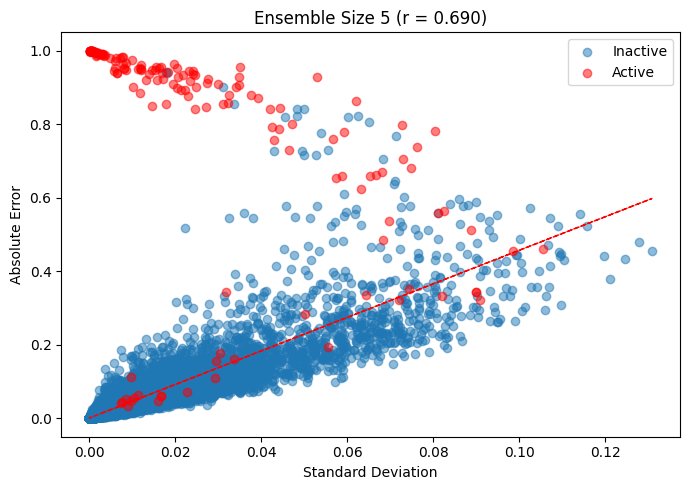

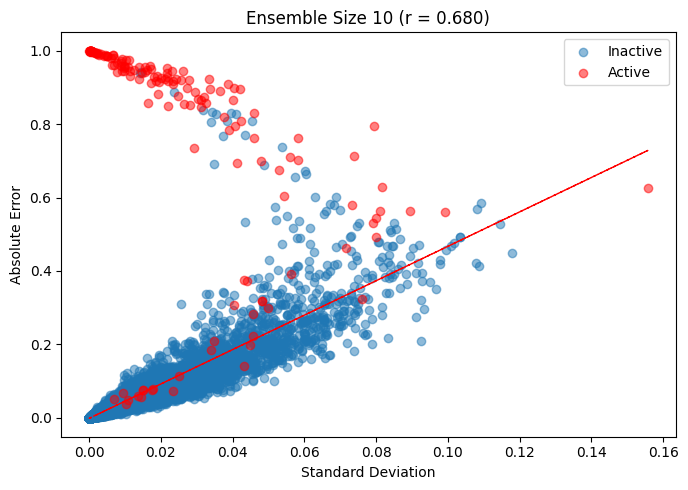

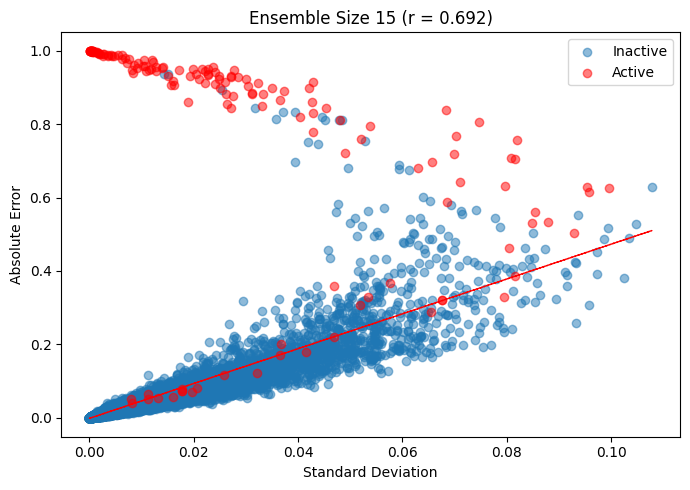

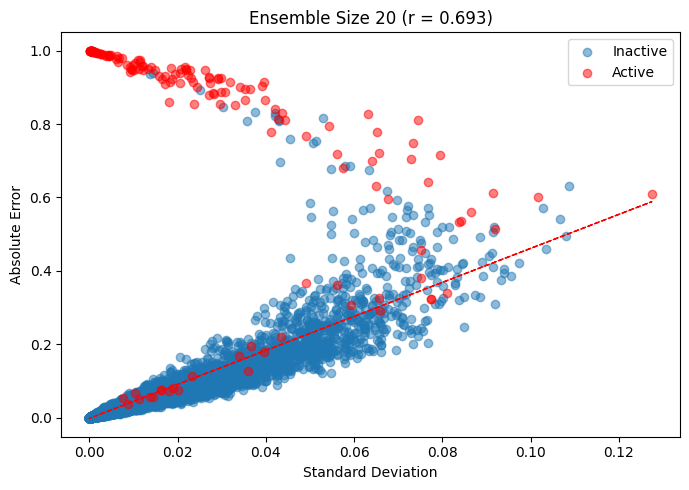

Ensemble size 5: Correlation between std_dev and absolute error = 0.6895
Ensemble size 10: Correlation between std_dev and absolute error = 0.6798
Ensemble size 15: Correlation between std_dev and absolute error = 0.6916
Ensemble size 20: Correlation between std_dev and absolute error = 0.6929


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

threshold = 0

data_filtered = data.copy()
data_filtered["error"] = np.abs(data_filtered[mean_col] - data_filtered['true_label'])
data_filtered = data_filtered[data_filtered["error"] > threshold]

ensemble_sizes = [5, 10, 15, 20]
correlations = {}

for size in ensemble_sizes:
    mean_col = f'mean_{size}_0'
    std_dev_col = f'std_dev_{size}_0'
    
    absolute_errors = np.abs(data_filtered[mean_col] - data_filtered['true_label'])
    correlation, _ = pearsonr(data_filtered[std_dev_col], absolute_errors)
    correlations[size] = correlation
    
    plt.figure(figsize=(7, 5))
    
    # ── scatter of inactives (true_label == 0) ──
    inactives = data_filtered[data_filtered['true_label'] == 0]
    plt.scatter(
        inactives[std_dev_col], 
        np.abs(inactives[mean_col] - inactives['true_label']),
        alpha=0.5, 
        label='Inactive'    )
    
    # ── scatter of actives (true_label == 1) ──
    actives = data_filtered[data_filtered['true_label'] == 1]
    plt.scatter(
        actives[std_dev_col], 
        np.abs(actives[mean_col] - actives['true_label']),
        alpha=0.5, 
        label='Active', 
        color='red'
    )
    
    # trend line for all points
    z = np.polyfit(data_filtered[std_dev_col], absolute_errors, 1)
    plt.plot(
        data_filtered[std_dev_col], 
        np.polyval(z, data_filtered[std_dev_col]), 
        'r--', 
        linewidth=1
    )
    
    plt.title(f'Ensemble Size {size} (r = {correlation:.3f})')
    plt.xlabel('Standard Deviation')
    plt.ylabel('Absolute Error')
    plt.legend()
    plt.tight_layout()
    
    filename = f"{'coadd' if coadd else 'collins'}_test_set_correlation_size_{size}_threshold_{threshold}.png"
    plt.show()
    plt.close()

# Correlation summary
for size, corr in correlations.items():
    print(f"Ensemble size {size}: Correlation between std_dev and absolute error = {corr:.4f}")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

def calibration_plot(df, k=5, n_bins=10):
    probs = df[f'mean_{k}_0']
    labels = df['true_label']
    
    frac_pos, mean_pred = calibration_curve(labels, probs, n_bins=n_bins)
    
    plt.plot(mean_pred, frac_pos, marker='o', label=f'Ensemble {k}')
    plt.plot([0, 1], [0, 1], '--', color='gray')
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Fraction of positives")
    plt.title("Reliability Diagram")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ECE
    bin_ids = np.digitize(probs, np.linspace(0, 1, n_bins + 1)) - 1
    ece = 0.0
    for i in range(n_bins):
        bin_mask = bin_ids == i
        if bin_mask.sum() == 0:
            continue
        bin_conf = probs[bin_mask].mean()
        bin_acc = labels[bin_mask].mean()
        ece += np.abs(bin_acc - bin_conf) * bin_mask.mean()
    print(f"Expected Calibration Error (ECE): {ece:.4f}")

def uncertainty_vs_error(df, k=5, bins=10):
    stds = df[f'std_dev_{k}_0']
    preds = df[f'mean_{k}_0'] > 0.5
    labels = df['true_label']
    errors = preds != labels
    
    df_temp = df.copy()
    df_temp['std_dev'] = stds
    df_temp['error'] = errors
    
    df_temp['bin'] = pd.qcut(df_temp['std_dev'], bins, duplicates='drop')
    grouped = df_temp.groupby('bin')['error'].mean()
    
    grouped.plot(marker='o')
    plt.fig()
    plt.xlabel("Uncertainty (std dev) bin")
    plt.ylabel("Error rate")
    plt.title("Error rate vs. predicted uncertainty")
    plt.grid(True)
    plt.show()

from sklearn.metrics import roc_auc_score, average_precision_score

def uncertainty_auroc(df, k=5):
    stds = df[f'std_dev_{k}_0']
    preds = df[f'mean_{k}_0'] > 0.5
    labels = df['true_label']
    errors = preds != labels

    auroc = roc_auc_score(errors, stds)
    auprc = average_precision_score(errors, stds)
    print(f"AUROC (Uncertainty as Error Predictor): {auroc:.4f}")
    print(f"AUPRC: {auprc:.4f}")

import seaborn as sns

def uncertainty_distributions(df, k=5):
    stds = df[f'std_dev_{k}_0']
    preds = df[f'mean_{k}_0'] > 0.5
    labels = df['true_label']
    correct = preds == labels

    sns.violinplot(x=correct, y=stds)
    plt.xticks([0, 1], ["Incorrect", "Correct"])
    plt.ylabel("Uncertainty (std dev)")
    plt.title("Uncertainty vs. Prediction Correctness")
    plt.grid(True)
    plt.show()

def selective_classification(df, k=5):
    df_temp = df.copy()
    df_temp['std_dev'] = df[f'std_dev_{k}_0']
    df_temp['mean'] = df[f'mean_{k}_0']
    df_temp['correct'] = (df_temp['mean'] > 0.5) == df_temp['true_label']

    df_sorted = df_temp.sort_values(by='std_dev')
    coverages = np.linspace(0.05, 1.0, 20)
    accuracies = []

    for c in coverages:
        cutoff = int(len(df_sorted) * c)
        acc = df_sorted.iloc[:cutoff]['correct'].mean()
        accuracies.append(acc)

    plt.plot(coverages, accuracies, marker='o')
    plt.xlabel("Coverage (fraction of predictions kept)")
    plt.ylabel("Accuracy")
    plt.title("Risk-Coverage Curve")
    plt.grid(True)
    plt.show()


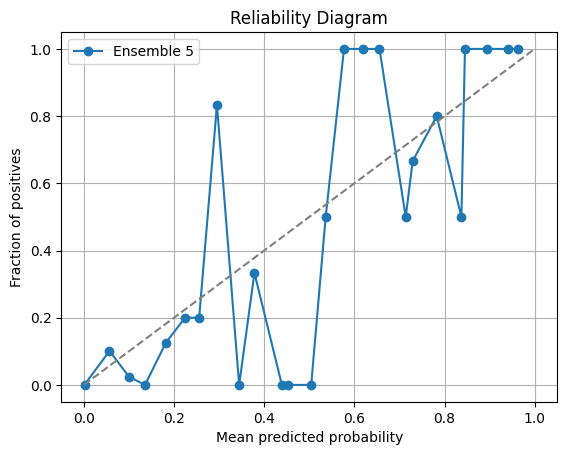

Expected Calibration Error (ECE): 0.0026


In [21]:
calibration_plot(data, k=5, n_bins=25)

/var/folders/3n/d_494yv542l36_6hmdd4rb1w0000gn/T/ipykernel_75286/2673438641.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df_temp.groupby('bin')['error'].mean()


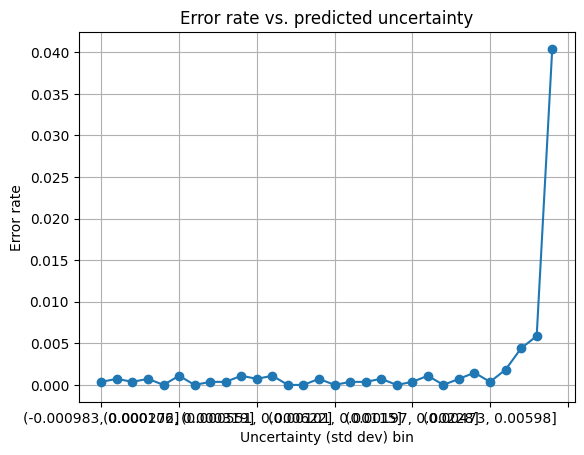

In [45]:
uncertainty_vs_error(data, k=20, bins=30)

AUROC (Uncertainty as Error Predictor): 0.8809
AUPRC: 0.0811


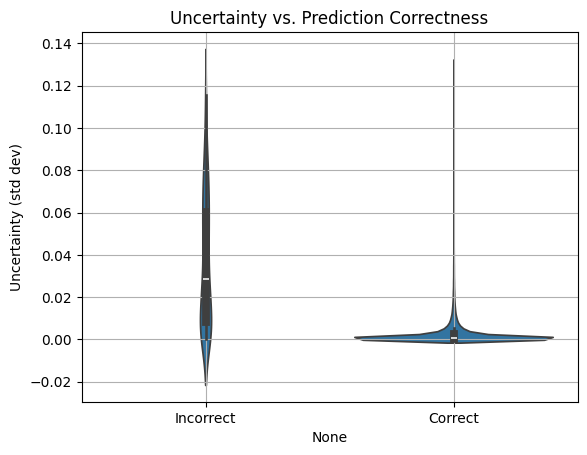

In [36]:
uncertainty_auroc(data, k=5)
uncertainty_distributions(data, k=5)

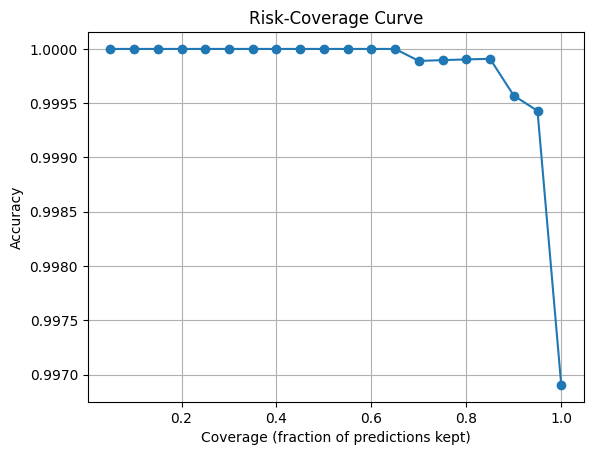

In [28]:
selective_classification(data)

In [41]:
from sklearn.metrics import roc_auc_score, average_precision_score, accuracy_score

def evaluate_predictions(df, k=5, threshold=0.5):
    # Extract mean predictions and labels
    probs = df[f'mean_{k}_0']
    labels = df['true_label']

    # Thresholded binary predictions
    preds = probs > threshold

    # Metrics
    acc = accuracy_score(labels, preds)
    auroc = roc_auc_score(labels, probs)
    auprc = average_precision_score(labels, probs)

    print(f"Accuracy @ threshold={threshold}: {acc:.4f}")
    print(f"AUROC (mean_pred vs true_label): {auroc:.4f}")
    print(f"AUPRC (mean_pred vs true_label): {auprc:.4f}")


evaluate_predictions(data, k=5)

Accuracy @ threshold=0.5: 0.9977
AUROC (mean_pred vs true_label): 0.8475
AUPRC (mean_pred vs true_label): 0.1700
